# 04 Visualize the results from all considered clustering approaches together.

Three datasets are available via the `dataset_chosen` key:

| key | description |
|---|---|
|`Slovakia`| Slovakian dataset with 1000 buildings measured in 2016|
|`Germany`| German dataset with 38 buildings measured from 2018 till 2020|
|`USA`| MFRED (USA) dataset with 26 buildings measured from 2019 till 2021|

> **Note** This file is also used to store the results from the basecase and theoretical upper bound (TUB) scenarios in the csv files.

In [2]:
import matplotlib as mpl
import numpy as np
from pathlib import Path

mpl.rcParams.update({
    "text.usetex": True,        # Enable LaTeX
    "font.family": "serif",     # Use a serif font
    "font.serif": ["Computer Modern"],  # LaTeX font
})

## 4.1 Selecting the input parameters.

In order to consider different scenarios, the relevant input parameters are given selected via their respective keys.

| keys | values | description |
|---|---|---|
|`dataset_chosen`|`Slovakia`, `Germany`, `USA`| Selects the dataset on which to do the analysis.|
|`trainVsTest`| `Train`, `Test`| Trains or tests the clustering algorithm. **This only affects the basecase and TUB result.**|
|`MAEVsRMSE`| `MAE`, `RMSE`| Uses MAE or RMSE metric **This only affects the basecase and TUB result.**|
|`input_period`|`year`, `month`, `seasonal`| Selects the input period to consider. **This only affects the TUB result.**|
|`resolution`|`15_min`, `hourly`, `daily`| Selects the resolution to consider. **This only affects the TUB result.**|

> **Note:** The input periods to select from consider the full year (`year`) of data, consider the most representative month (`month`) of data, or consider each full season separately (`seasonal`).

In [3]:
dataset_chosen = "USA"
trainVsTest = "Test"
MAEVsRMSE = "RMSE"
input_period = "month"
resolution = "15_min"

## 4.2 Calculating the basecase and TUB results.

### 4.2.1 Loading and preprocessing the data.

In [4]:
import general_clustering_functions as gcf
project_root = Path().resolve()

if dataset_chosen == "Slovakia":
    path_folder = project_root / "data" / "repository" / "Slovakia"
elif dataset_chosen == "Germany":
    path_folder = project_root / "data" / "repository" / "Germany"
elif dataset_chosen == "USA":
    path_folder = project_root / "data" / "repository" / "USA"

if trainVsTest == "Train":
    power_dict, houses = gcf.loading_cleaned_files(path_folder, "power_dict_train.zip", dataset_chosen)
elif trainVsTest == "Test":
    power_dict, houses = gcf.loading_cleaned_files(path_folder, "power_dict_test.zip", dataset_chosen)
    
print(power_dict[list(power_dict.keys())[0]].head())

Error removing C:\Users\u0181580\OneDrive - KU Leuven\PHD\Julia\clean_code_thesis\clustering\data\repository\USA\extracted_dataframes: (<class 'PermissionError'>, PermissionError(13, 'Toegang geweigerd'), <traceback object at 0x0000017A829DCB40>)
                           Nr       P       Q         S        PF  PV
DateTimeUTC                                                          
2021-01-01 00:00:00-05:00   1  0.0229  0.0039  0.023230  0.985806   0
2021-01-01 00:15:00-05:00   1  0.0378  0.0120  0.039659  0.953124   0
2021-01-01 00:30:00-05:00   1  0.0267  0.0003  0.026702  0.999937   0
2021-01-01 00:45:00-05:00   1  0.0256  0.0027  0.025742  0.994484   0
2021-01-01 01:00:00-05:00   1  0.0349  0.0053  0.035300  0.988665   0


In [5]:
power_dict_timed, month_length_31, Summer_length, Winter_length, Fall_length, Spring_length = gcf.adapting_data_resolution(power_dict, resolution, dataset_chosen)

if input_period == "seasonal":
    Summer_data_timed, Fall_data_timed, Winter_data_timed, Spring_data_timed, Summer_data, Fall_data, Winter_data, Spring_data = gcf.seasonal_data(power_dict_timed, power_dict, month_length_31, Summer_length, Winter_length, Fall_length, Spring_length, dataset_chosen, "0", "Unimportant")

### 4.2.2 Calculate the basecase results.

In [6]:
import visualization_results as vr

best_PF, basecase = gcf.basecase(power_dict, MAEVsRMSE)
if input_period == "seasonal":
    basecase_error_over_time_summer = vr.Basecase_time(Summer_data, houses, best_PF)
    basecase_error_over_time_winter = vr.Basecase_time(Winter_data, houses, best_PF)
    basecase_error_over_time_spring = vr.Basecase_time(Spring_data, houses, best_PF)
    basecase_error_over_time_fall = vr.Basecase_time(Fall_data, houses, best_PF)
else:
    basecase_error_over_time = vr.Basecase_time(power_dict, houses, best_PF)
print(f"Best PF: {best_PF}, Basecase error: {basecase}")

[0.32044, 0.3085, 0.29657, 0.28464, 0.27267, 0.26064, 0.24853, 0.2363, 0.22392, 0.21134, 0.19851, 0.18536, 0.17183, 0.1578, 0.14315, 0.1277, 0.11123, 0.09347, 0.07446, 0.06622]
Best PF: 1.0, Basecase error: 0.06622


### 4.2.3 Calculating TUB error.

In [7]:
if input_period == "seasonal":
    tub_error_summer, tub_PF_list_summer = gcf.optimal_error(Summer_data_timed, Summer_data, MAEVsRMSE)
    tub_error_fall, tub_PF_list_fall = gcf.optimal_error(Fall_data_timed, Fall_data, MAEVsRMSE)
    tub_error_winter, tub_PF_list_winter = gcf.optimal_error(Winter_data_timed, Winter_data, MAEVsRMSE)
    tub_error_spring, tub_PF_list_spring = gcf.optimal_error(Spring_data_timed, Spring_data, MAEVsRMSE)
    Estimation_error = tub_error_summer + tub_error_fall + tub_error_winter + tub_error_spring
else:
    tub_error, tub_PF_list = gcf.optimal_error(power_dict_timed, power_dict, MAEVsRMSE)
    Estimation_error = tub_error

if MAEVsRMSE == "MAE":
    Error_tot = Estimation_error/(len(power_dict)*len(power_dict[list(power_dict.keys())[0]]['P']))
else:
    Error_tot = np.sqrt((Estimation_error)/len(power_dict)/len(power_dict[list(power_dict.keys())[0]]['P']))

print(round(Error_tot,5))
improvement_tub = 1 - (Error_tot/basecase)
print(improvement_tub)

0.05022
0.241611094080594


### 4.2.4 Store the basecase and TUB results.

In [ ]:
path_folder = project_root / "data" / "repository"
gcf.writing_result_benchmark_scenarios(path_folder, dataset_chosen, trainVsTest, resolution, input_period, MAEVsRMSE, basecase, Error_tot, improvement_tub)

NameError: name 'project_root' is not defined

## 4.3 Visualizing all clustering results

Loading the results.

In [25]:
results_df = vr.read_all_clustering_results(path_folder, dataset_chosen, "hierarchical", MAEVsRMSE)

        11       12        13        14        15        16        17
0  0.06622  0.05000  0.064440  0.050753  0.050753  0.050753  0.050753
1  0.06622  0.05000  0.064440  0.050555  0.052682  0.050555  0.050857
2  0.06622  0.05000  0.064437  0.050856  0.066217  0.050856  0.061244
3  0.06622  0.05000  0.064440  0.051873  0.051873  0.051873  0.066217
4  0.06622  0.05000  0.058255  0.051979  0.051979  0.050415  0.050857
5  0.06622  0.05000  0.061208  0.050528  0.065067  0.050845  0.050837
6  0.06622  0.04582  0.058584  0.047100  0.047610  0.046393  0.047097
7  0.06622  0.04583  0.058743  0.047488  0.046200  0.046819  0.046789
8  0.06622  0.04587  0.058389  0.052855  0.056238  0.050316  0.052012


Plotting the different clustering approaches.

In [26]:

print(results_df.shape)
print(results_df.columns)
print(results_df.head())


(9, 7)
Index(['BC', 'TUB', 'PF_time', 'PQ_Pearson', 'PQSPF_Pearson', 'PQ_PCA',
       'PQSPF-PCA'],
      dtype='str')
        BC   TUB   PF_time  PQ_Pearson  PQSPF_Pearson    PQ_PCA  PQSPF-PCA
0  0.06622  0.05  0.064440    0.050753       0.050753  0.050753   0.050753
1  0.06622  0.05  0.064440    0.050555       0.052682  0.050555   0.050857
2  0.06622  0.05  0.064437    0.050856       0.066217  0.050856   0.061244
3  0.06622  0.05  0.064440    0.051873       0.051873  0.051873   0.066217
4  0.06622  0.05  0.058255    0.051979       0.051979  0.050415   0.050857


  Approach     RMSE
0       BC  0.06622
1       BC  0.06622
2       BC  0.06622
3       BC  0.06622
4       BC  0.06622
Approach        str
RMSE        float64
dtype: object
<StringArray>
['BC', 'TUB', 'PF_time', 'PQ_Pearson', 'PQSPF_Pearson', 'PQ_PCA', 'PQSPF-PCA']
Length: 7, dtype: str


<Figure size 800x600 with 0 Axes>

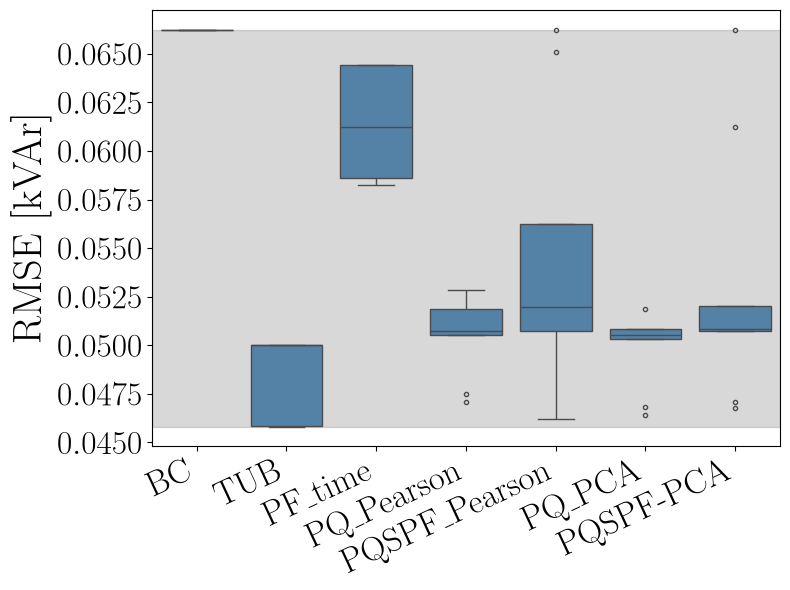

In [27]:
vr.comparison_clustering_approaches(results_df)

Plotting the different input cases.

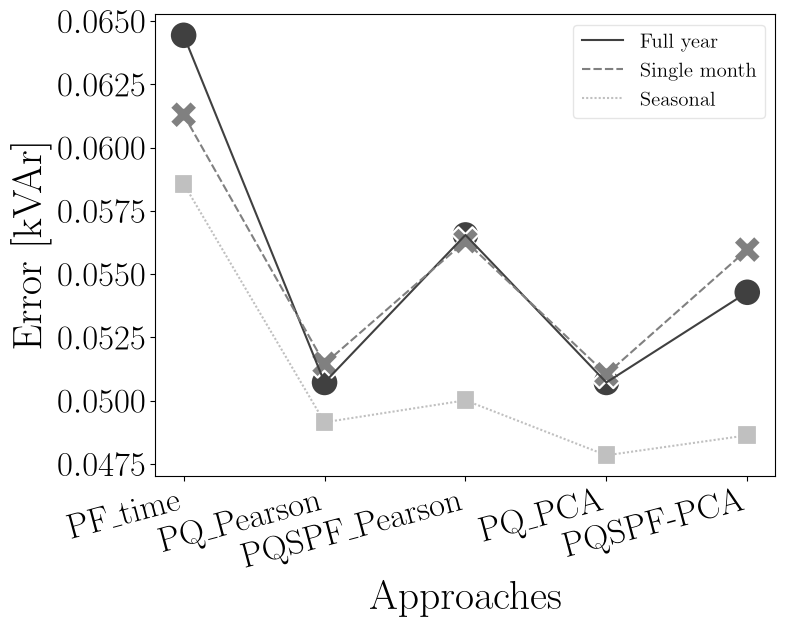

In [34]:
vr.plot_input_scenarios(results_df)